## ARIMA For Process Behavior Estimation using the Box-Jenkins Method
### Mixed Intensity GP Workloads
#### Braden Everson

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import math

In [2]:
series = pd.read_csv("../gp-workloads/time_slices/mixed_11/mixed_11_waitrun_5000us.csv")
# series = pd.read_csv("../gp-workloads/time_slices/mixed_13/mixed_13_waitrun_5000us.csv")
# series = pd.read_csv("../gp-workloads/time_slices/mixed_14/mixed_14_waitrun_500us.csv")

In [3]:
series

,bin_index,start_time_us,end_time_us,waiting_time_us,running_time_us,waiting_pct,running_pct
0,0,0,5000,280,4720,5.600000,94.400000
1,1,5000,10000,168,4832,3.360000,96.640000
2,2,10000,15000,225,4775,4.500000,95.500000
3,3,15000,20000,98,4902,1.960000,98.040000
4,4,20000,25000,3456,1544,69.120000,30.880000
...,...,...,...,...,...,...,...
474,474,2370000,2375000,5000,0,100.000000,0.000000
475,475,2375000,2380000,2813,2187,56.260000,43.740000
476,476,2380000,2385000,5000,0,100.000000,0.000000
477,477,2385000,2390000,5000,0,100.000000,0.000000


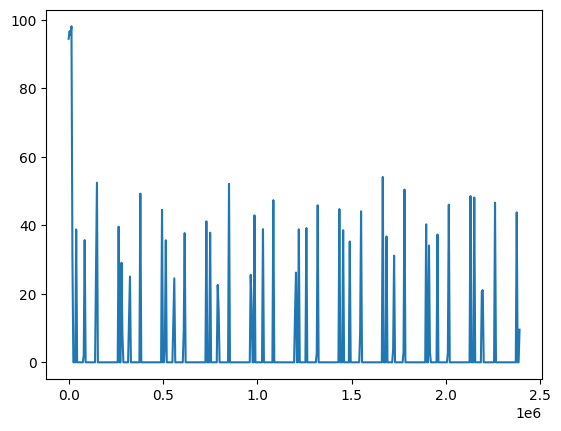

In [4]:
plt.plot(series["start_time_us"], series["running_pct"])

## ARIMA to Predict the final value

In [5]:
model = ARIMA(series["running_pct"], order=(5, 1, 0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=1)
print(f"Predicted running_pct: {forecast.iloc[0]:.2f}")

Predicted running_pct: 13.72


## ARIMA at "run-time", collecting deltas off as we go

In [6]:
pred = []

for i in range(5, len(series["running_pct"])):
    model = ARIMA(series["running_pct"][0:i], order=(5, 1, 0))
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=1).iloc[0]
    pred.append(forecast)

/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_r

In [7]:
len(pred)

474

In [8]:
len(series["running_pct"])

479

We don't start with any predictions before we have at least 5 samples to look back to, let's just assume 50% CPU utilization is the placeholder for these cases

In [9]:
padding = [50,50,50,50,50]

pred = padding + pred

Text(0.5, 1.0, 'Actual Running Percentage')

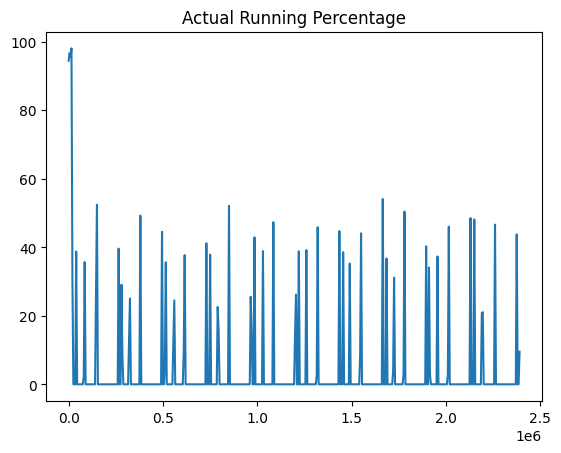

In [10]:
plt.plot(series["start_time_us"], series["running_pct"])
plt.title("Actual Running Percentage")

Text(0.5, 1.0, 'Predicted Running Percentage')

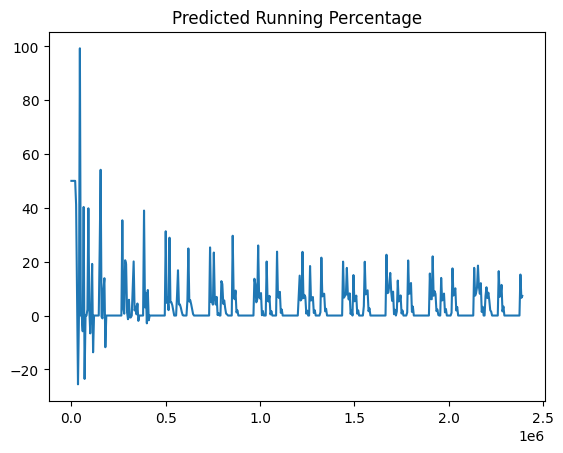

In [11]:
plt.plot(series["start_time_us"], pred)
plt.title("Predicted Running Percentage")

In [12]:
pred_arr = np.array(pred)
off = series["running_pct"] - pred_arr

Text(0.5, 1.0, 'Actual - Predicted Running Percentage')

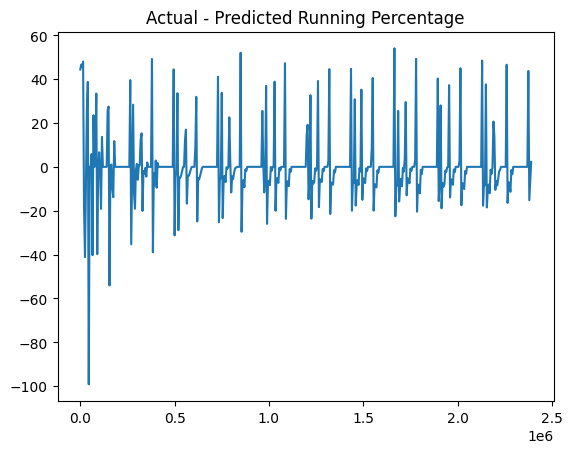

In [13]:
plt.plot(series["start_time_us"], off)

plt.title("Actual - Predicted Running Percentage")

In general, *close* but never exactly there. Spikes are properly seen but are never the same magnitude as the true spikes down

In [14]:
rmse = math.sqrt((off ** 2).sum() / len(off))

print(f"RMSE: {rmse:.2f}")

RMSE: 15.06
